<a href="https://colab.research.google.com/github/kaustavya/Pluto-Academy-EDA-Project/blob/main/Pluto_Academy_Project_01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [8]:
import pandas as pd
import os

csv_file_path = os.path.join(path, "netflix_titles.csv")

# Load the dataset into a variable called 'df' (DataFrame)
df = pd.read_csv(csv_file_path)

# Check the shape (Rows, Columns)
print("Dataset Shape:", df.shape)

# Look at the column names and data types
print("\nData Types")
print(df.dtypes)

# Check for missing values
print("\n Missing Values ")
print(df.isnull().sum())

# See the first 5 rows of data
df.head()

Dataset Shape: (8807, 12)

Data Types
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

 Missing Values 
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
# Drop duplicate rows
df = df.drop_duplicates()

# Handle missing values (NaN)
# Since we cannot guess a movie's director or cast, we will replace empty spaces with "Unknown"
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# For 'date_added' and 'rating', there are usually very few missing values.
df = df.dropna(subset=['date_added', 'rating'])

# Verifying; if the cleaning worked
print(" issing Values After Cleaning  ")
print(df.isnull().sum())
print("\nNew Dataset Shape:", df.shape)

 issing Values After Cleaning  
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

New Dataset Shape: (8793, 12)


In [10]:
# Drop the remaining rows missing a duration
df = df.dropna(subset=['duration'])

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (8790, 12)


In [11]:
print("  1. What is the breakdown of Movies vs. TV Shows?  ")
print(df['type'].value_counts())
print("\n")

print("  2. What are the top 5 countries producing content?  ")

print(df['country'].value_counts().head(5))
print("\n")

print("  3. What are the top 5 years with the most content added?  ")
print(df['release_year'].value_counts().head(5))
print("\n")

print("  4. What are the most common age ratings on Netflix?  ")
print(df['rating'].value_counts().head(5))
print("\n")

print("  5. What are the top 5 most frequent genres (listed_in)?  ")
print(df['listed_in'].value_counts().head(5))

  1. What is the breakdown of Movies vs. TV Shows?  
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


  2. What are the top 5 countries producing content?  
country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
Name: count, dtype: int64


  3. What are the top 5 years with the most content added?  
release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
Name: count, dtype: int64


  4. What are the most common age ratings on Netflix?  
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64


  5. What are the top 5 most frequent genres (listed_in)?  
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    25

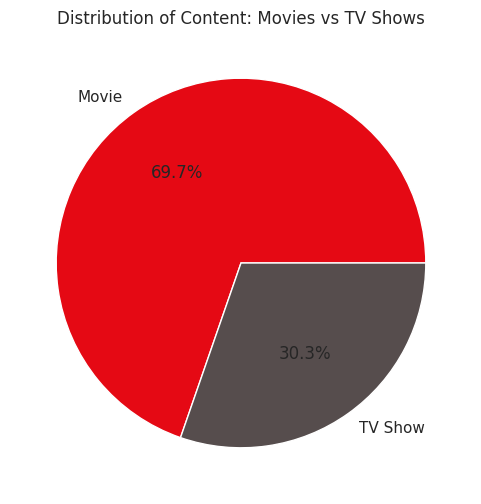

/tmp/ipykernel_679/3493675677.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index[:10], palette='viridis')


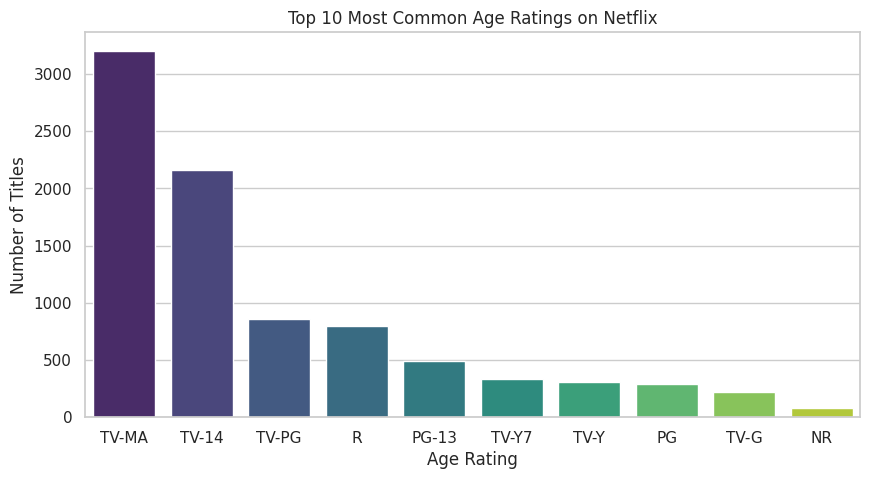

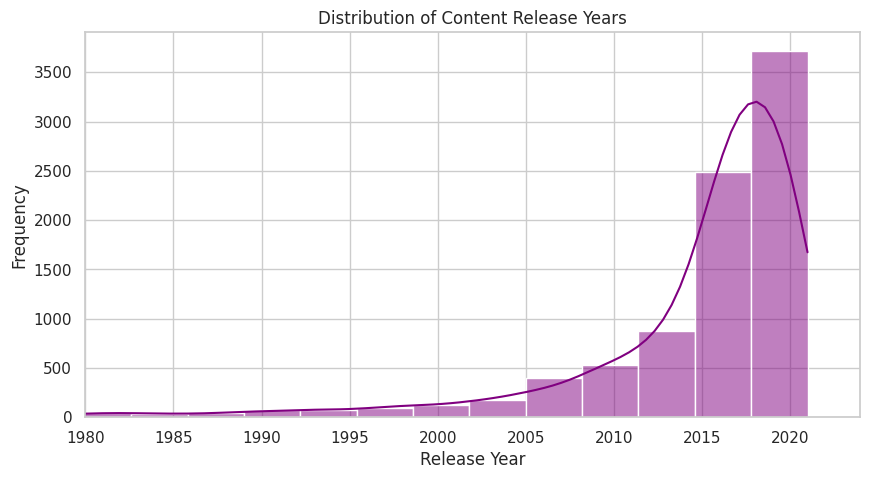

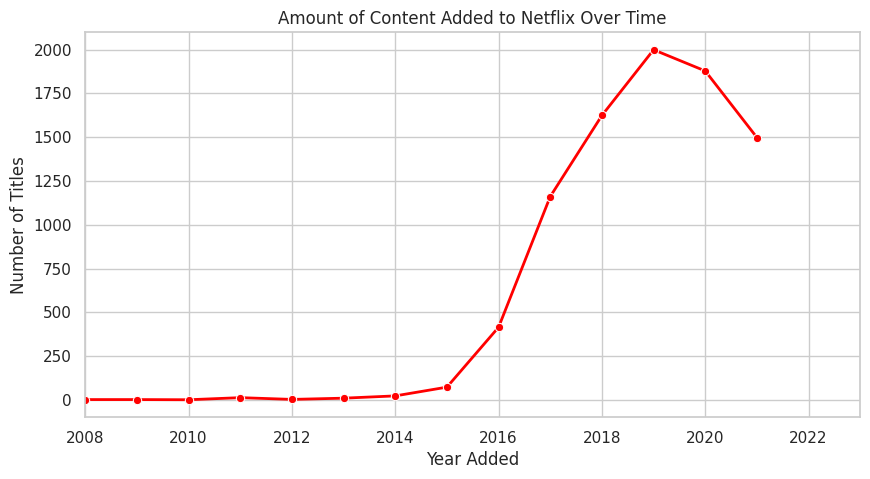

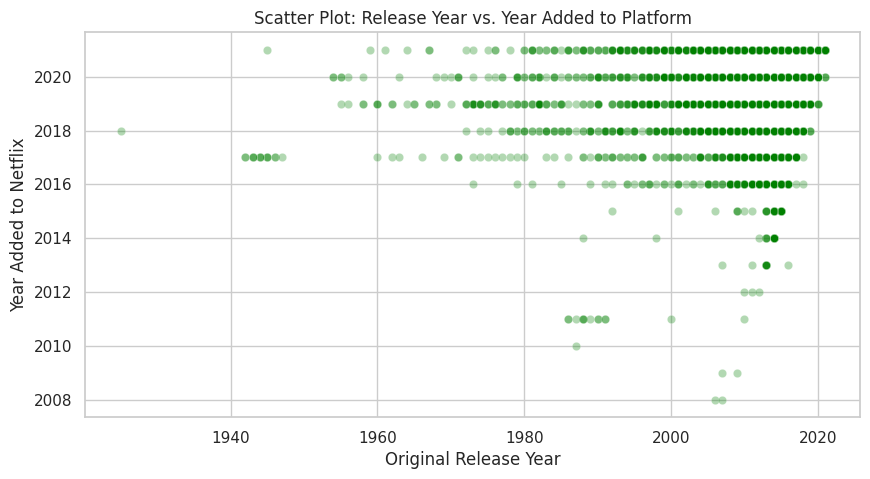

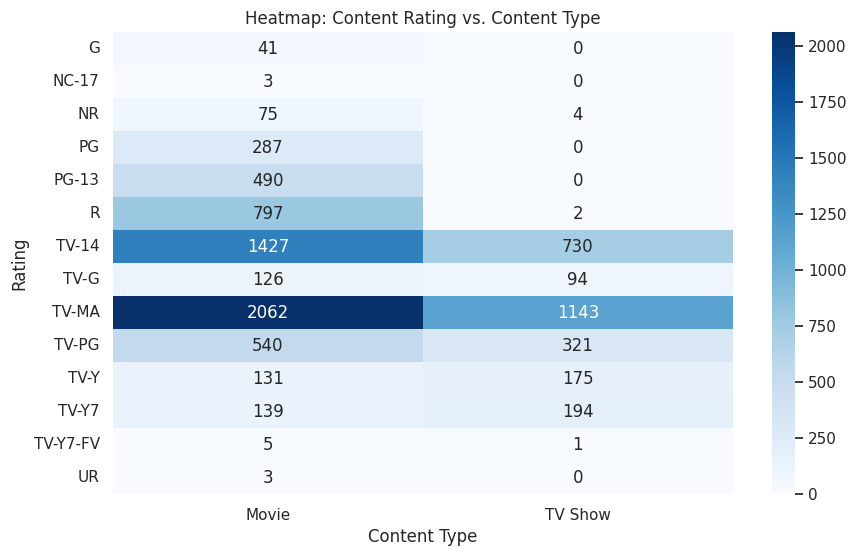

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style for the charts
sns.set_theme(style="whitegrid")


df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year

# PIE CHART: Movies vs TV Shows
plt.figure(figsize=(6, 6))
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#e50914', '#564d4d'])
plt.title('Distribution of Content: Movies vs TV Shows')
plt.ylabel('')
plt.show()

# BAR CHART: Top 10 age ratings
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Most Common Age Ratings on Netflix')
plt.xlabel('Age Rating')
plt.ylabel('Number of Titles')
plt.show()

# HISTOGRAM: Distribution of release years
plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.xlim(1980, 2024) # Zooming in to the most relevant years
plt.show()

# LINE CHART: Content Added Over Time
plt.figure(figsize=(10, 5))
year_counts = df['year_added'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='red', linewidth=2)
plt.title('Amount of Content Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xlim(2008, 2023)
plt.show()


# SCATTER PLOT: Release Year vs. Year Added
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='release_year', y='year_added', alpha=0.3, color='green')
plt.title('Scatter Plot: Release Year vs. Year Added to Platform')
plt.xlabel('Original Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

# HEATMAP: Content Rating vs Content Type
plt.figure(figsize=(10, 6))
# Creating a matrix for Rating vs Type
rating_type_cross = pd.crosstab(df['rating'], df['type'])
sns.heatmap(rating_type_cross, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap: Content Rating vs. Content Type')
plt.xlabel('Content Type')
plt.ylabel('Rating')
plt.show()

Insights Report

1. Content Distribution (Pie Chart): Movies dominate the Netflix platform, making up a significantly larger portion of the catalog compared to TV Shows.

2. Target Audience (Bar Chart): The most common age rating on the platform is TV-MA (Mature Audiences), indicating that Netflix heavily prioritizes adult-oriented content over kids' shows.

3. Platform Growth (Line Chart & Histogram): There was an explosive growth in content added to the platform starting around 2015, peaking recently before plateauing.

4. Top Producers (EDA Analysis): The United States is the primary producer of content on the platform, with India coming in as a strong second.

5. Release vs. Added (Scatter Plot): The scatter plot shows that while Netflix adds a lot of brand-new releases, they also steadily acquire and add older classic movies from decades past.

Going into this, I assumed the split between Movies and TV Shows would be roughly 50/50, considering how much Netflix promotes its original series. I was highly surprised to see just how massively movies outnumber TV shows. Additionally, the  volume of international content, specifically from India, was unexpectedly high compared to typical television networks.